# News2Stock QLoRA 파인튜닝

BF16 base model에 LoRA adapter를 붙여 금융 뉴스 분석 형식을 학습했다.

이번에는 데이터·정답 mask·SFT·평가 흐름을 그대로 유지하고, **base model을 NF4 4비트로 적재하는 부분만 새로 확장**한다.

QLoRA의 핵심은 8B base weight를 4비트로 저장해 VRAM을 줄이면서, 행렬 연산은 BF16으로 수행하고 LoRA adapter만 학습하는 것이다.

`LoRA → 4비트 저장 → k-bit 학습 준비 → adapter 학습 → 4비트 추론 재적재` 순서로 차이를 확인한다.


## 양자화란 무엇인가

양자화(quantization)는 model weight를 BF16과 같은 높은 정밀도의 실수로 저장하는 대신, <br>
 제한된 개수의 대표값에 대응하는 작은 bit code로 근사해 저장하는 기술이다. QLoRA에서는 이미 학습된 base model의 weight를 더 적은 VRAM에 올리기 위해 이 방법을 사용한다.

4비트로 표현할 수 있는 code는 `2⁴ = 16개`이다. 따라서 서로 다른 수많은 실수 weight를 그대로 보존하지 않고, 각 값을 16개 대표값 중 가장 가까운 값에 연결한다.

개념적으로 원래 weight `0.613`을 대표값 `0.600`으로 바꾸면 `0.013`의 차이가 생기는데, 이를 **양자화 오차(quantization error)** 라고 한다. <br>
실제 NF4는 weight를 block 단위로 나누고 scale로 정규화한 뒤, 정규분포에 맞춘 16개 대표값을 사용한다.

이때 저장과 복원에는 다음 세 요소가 사용된다.

- **4비트 code**는 16개 대표값 중 어떤 값을 선택했는지 나타내는 번호이다.
- **codebook**은 각 code가 가리키는 16개 대표값의 목록이다.
- **scale**은 block 안의 weight 크기를 정규화하고 다시 복원할 때 사용하는 값이다.

양자화와 역양자화는 다음 순서로 이어진다.

```text
BF16 weight
→ block별 scale 계산과 정규화
→ 가장 가까운 NF4 대표값의 4비트 code 선택
→ 4비트 code와 block별 scale 저장         [양자화]
→ NF4 codebook과 scale로 BF16 근삿값 변환 [역양자화]
→ BF16으로 계산
```

**양자화(quantization)**는 높은 정밀도 weight를 낮은 bit 표현으로 바꾸는 과정이고, **역양자화(dequantization)**는 저장된 code와 scale로 계산에 사용할 근삿값을 복원하는 과정이다. 역양자화는 원래 값을 완벽하게 되돌리는 과정이 아니므로 메모리를 줄이는 대신 작은 오차가 남을 수 있다.

QLoRA에서는 base weight만 4비트로 저장하고 고정한다. 실제 업무 지식을 학습하는 LoRA adapter만 gradient를 받아 갱신된다. 따라서 QLoRA는 ‘4비트 base model 전체를 직접 학습하는 방법’이 아니라, **고정된 4비트 base를 이용하면서 LoRA adapter만 학습하는 방법**이다.


## LoRA에서 QLoRA로 넘어가기

QLoRA는 새로운 adapter 학습법이 아니라 **LoRA의 저랭크 adapter 학습은 그대로 두고, 고정할 base weight의 저장 형식을 4비트로 바꾼 방법**이다.

| 구분 | 04번 LoRA | 05번 QLoRA |
|---|---|---|
| base weight 저장 | BF16, 파라미터당 16비트 | NF4, 파라미터당 4비트 |
| 행렬곱 계산 | BF16 | 4비트 weight를 BF16으로 복원해 계산 |
| 학습 대상 | LoRA adapter | LoRA adapter |
| 데이터·labels·SFT | News2Stock와 assistant-only loss | 04번과 동일 |
| 새 준비 작업 | LoRA 설정 | 4비트 적재와 k-bit 학습 준비 추가 |

04번의 LoRA 계산을 `Y = X(W_BF16 + ΔW_LoRA)`라고 쓸 수 있다. QLoRA에서는 `Ŵ = dequant(W_NF4, scale)`로 4비트 code를 계산용 근삿값으로 복원한 뒤, `Y = X(Ŵ + ΔW_LoRA)`를 계산한다. 두 식에서 실제로 학습되는 것은 `ΔW_LoRA = B @ A`이고, `Ŵ`는 고정된 base weight의 근삿값이다.

따라서 **양자화는 메모리를 줄이는 역할**, **LoRA adapter는 업무 지식을 학습하는 역할**을 맡는다. `BitsAndBytesConfig`가 base model의 저장 방식을 정하고, `LoraConfig`와 `SFTTrainer`가 실제 학습 범위를 정한다.


### QLoRA 원 논문의 구조 그림으로 확인하기

아래 Figure 1은 Full Fine-tuning, LoRA, QLoRA가 base model과 adapter를 어떤 정밀도로 저장하고 어느 부분을 학습하는지 비교한다.

- **왼쪽 Full Fine-tuning**은 16비트 base model 전체를 갱신하며, 32비트 optimizer state까지 유지한다.
- **가운데 LoRA**는 16비트 base model을 고정하고, 추가한 16비트 LoRA adapter만 학습한다.
- **오른쪽 QLoRA**는 고정된 base model을 4비트로 저장하고, 16비트 LoRA adapter만 학습한다. Paged Optimizer를 사용할 때 optimizer state의 일부는 CPU memory와 오갈 수 있다.
- 그림에서 파란색은 parameter update, 초록색은 gradient, 자홍색은 paging 흐름을 나타낸다.

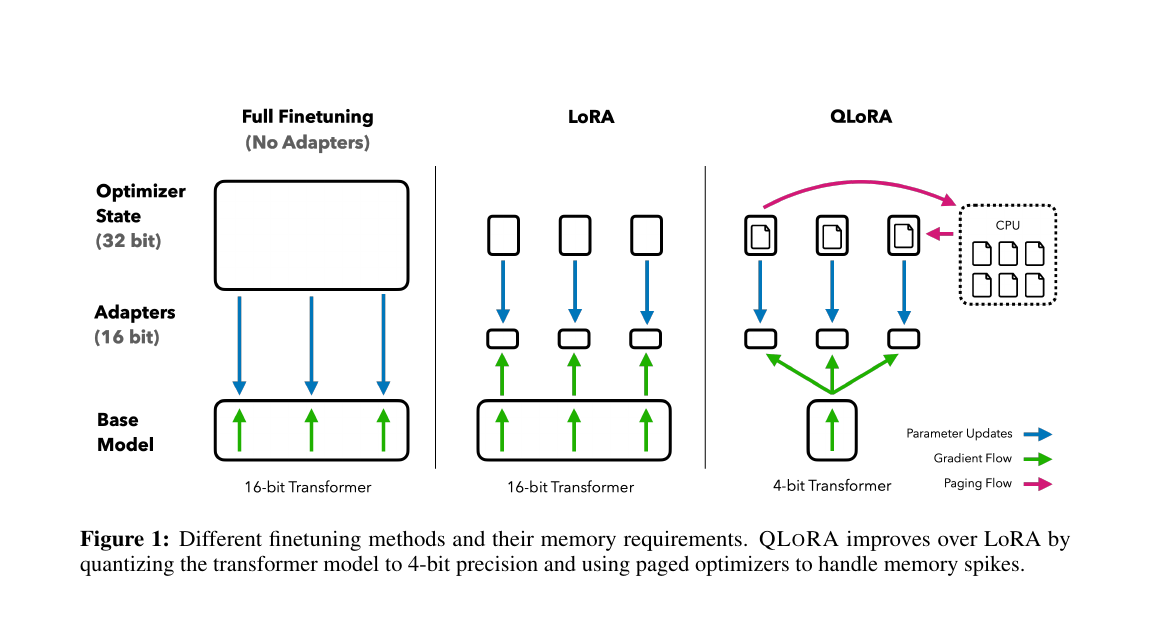

> 출처: [Dettmers et al., *QLoRA: Efficient Finetuning of Quantized LLMs*, Figure 1](https://arxiv.org/abs/2305.14314), NeurIPS 2023, [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). 원본 Figure 1을 PNG로 변환하고 여백을 잘라 사용한다.

이 그림은 **무엇을 4비트로 저장하고 무엇을 학습하는지**를 설명한다. 실수를 4비트 code에 대응시키는 NF4의 수치 변환 과정은 앞 절의 `양자화 → 역양자화` 흐름으로 구분해 이해한다.


## 4비트가 줄이는 메모리와 줄이지 못하는 메모리

8B는 약 80억 개의 파라미터를 뜻한다. <br>
base weight만 단순 계산하면 BF16은 파라미터당 2 byte이므로 약 `80억 × 2 byte = 16 GB`, <br>
4비트는 파라미터당 0.5 byte이므로 약 `80억 × 0.5 byte = 4 GB`가 필요하다. <br>
이 계산은 QLoRA가 8B 모델을 더 작은 GPU에서 다룰 수 있게 하는 이유를 보여 준다.

다만 전체 학습 VRAM이 정확히 16 GB에서 4 GB로 줄어들지는 않는다. 실제 GPU에는 다음 항목도 함께 존재한다.

- block별 quantization scale과 double quantization metadata가 존재한다.
- 4비트 weight는 행렬곱 직전에 BF16으로 복원되어 계산된다.
- activation, LoRA adapter, gradient, optimizer state와 CUDA 작업 공간이 추가된다.

즉, 4비트는 **고정된 base weight의 저장 비용**을 크게 줄이는 기술이며, 학습 과정에서 필요한 모든 메모리를 4분의 1로 만드는 기술과는 다르다. 연산할 때 dequantization이 추가되고 양자화 오차도 생기므로, QLoRA가 LoRA보다 항상 빠르거나 항상 정확한 결과를 보장하지 않는다.


## 환경설정

04번과 같은 RunPod 외부 Jupyter kernel을 사용한다. QLoRA에서 새로 필요한 패키지는 NVIDIA GPU의 4비트 weight 적재를 담당하는 `bitsandbytes`이다. 연결 과정은 [RunPod SSH·PyCharm 연결](../10_sllm/02_runpod_ssh_pycharm.ipynb)을 참고한다.

`HF_HOME=/workspace/cache/huggingface`와 공개 모델·Dataset 다운로드 조건도 04번과 같다. `HF_TOKEN`은 선택적 Hub 업로드에만 사용하며, 자세한 환경변수 설정은 [Hugging Face 모델·환경변수 준비](../10_sllm/03_sllm.ipynb)를 참고한다.


In [1]:
%pip install -U "transformers==4.56.2" "accelerate>=1,<2" "trl==0.22.2" "peft==0.17.1" "datasets==3.6.0" "bitsandbytes==0.47.0" hf_transfer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 104.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.8/544.8 kB 17.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 181.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 134.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 108.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 119.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 75.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 238.1 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.8/801.8 kB 32.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 149.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25/25 [trl]32m24/25 [trl]sets]e]s]ub]
Note: you may need to restart the kernel to use updated p

### GPU와 패키지 버전 확인

설치 셀 실행 후 현재 kernel이 RunPod GPU와 설치한 라이브러리를 사용하는지 한 번 확인한다. Pod에 등록한 `HF_TOKEN` 같은 환경변수는 외부 Jupyter server가 시작될 때 kernel에 전달되므로 이 노트북에서 `.env`를 다시 읽지 않는다.


In [2]:
import torch
import accelerate, bitsandbytes, datasets, peft, transformers, trl

print("torch:", torch.__version__)
print("CUDA available?:", torch.cuda.is_available())
# True이면 bitsandbytes가 사용할 RunPod GPU 이름까지 출력한다.
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("accelerate:", accelerate.__version__)
print("trl:", trl.__version__)
print("peft:", peft.__version__)
print("bitsandbytes:", bitsandbytes.__version__)

torch: 2.8.0+cu128
CUDA available?: True
GPU: NVIDIA A100-SXM4-80GB
transformers: 4.56.2
datasets: 3.6.0
accelerate: 1.14.0
trl: 0.22.2
peft: 0.17.1
bitsandbytes: 0.47.0


## 데이터 로드와 메시지 변환

양자화는 model weight의 저장 방식만 바꾸므로 Dataset 계약은 달라지지 않는다. 04번과 동일하게 공개 News2Stock 1,000건을 학습 800건과 평가 200건으로 나누고, 각 행을 `system → user → assistant` messages로 변환한다.


In [3]:
from datasets import Dataset, load_dataset
import json

dataset = load_dataset("shqkel/naver-economy-news2stock")

print(dataset)

README.md:   0%|          | 0.00/347 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['system', 'user', 'assistant'],
        num_rows: 1000
    })
})


In [4]:
print(len(dataset["train"]))


# 학습/평가 데이터 분기
test_ratio = 0.2

train_data, test_data = [], []

data_indices = list(range(len(dataset['train'])))
test_size = int(len(data_indices) * test_ratio)

test_index = data_indices[:test_size] # 0 ~ 199 평가셋
train_index = data_indices[test_size:] # 200 ~ 999 학습셋



import json
# system, user, assistant의 구조로 변환

# assistant 딕셔너리는 작은따옴표의 Python 표현이 아니라 JSON 문자열 계약으로 직렬화한다.
def format_data(data):
    return {
        "messages": [
            {"role": "system", "content": data["system"]},
            {"role": "user", "content": data["user"]},
            {"role": "assistant", "content": json.dumps(data["assistant"], ensure_ascii=False)},
        ]
    }

train_dataset = [format_data(dataset['train'][i]) for i in train_index]
test_dataset = [format_data(dataset['train'][i]) for i in test_index]

print('학습셋:', len(train_dataset))
print('평가셋:', len(test_dataset))

test_dataset[0]

# HuggingFace Dataset으로 변환
from datasets import Dataset

train_dataset = Dataset.from_list(train_dataset)
test_dataset = Dataset.from_list(test_dataset)

1000
학습셋: 800
평가셋: 200


## NF4 4비트 Base model 적재

`BitsAndBytesConfig`는 base model을 GPU에 올릴 때 어떤 4비트 형식으로 저장하고 어떤 dtype으로 계산할지 정한다. 이 실습에서는 QLoRA 논문에서 제안한 NF4와 double quantization을 사용한다.

- `load_in_4bit=True`는 Linear 계층의 base weight를 4비트로 적재한다. 이미 학습된 값을 근사해서 저장하며, 이 설정 자체가 새로운 업무 지식을 학습시키지는 않는다.
- `bnb_4bit_quant_type='nf4'`는 정규분포에 가까운 사전학습 weight에 맞춘 16개의 대표값으로 각 weight를 표현한다. 일반적인 균일 4비트 구간보다 사전학습 weight의 분포를 보존하는 데 유리하다.
- `bnb_4bit_use_double_quant=True`는 weight block의 범위를 복원하는 scale 값까지 다시 양자화한다. weight만 4비트로 만드는 것보다 metadata 비용을 파라미터당 약 0.4비트 더 줄인다.
- `bnb_4bit_compute_dtype=torch.bfloat16`은 저장된 4비트 값을 행렬곱할 때 BF16으로 복원해 계산한다. **저장은 4비트이고 계산은 BF16**이라는 두 dtype을 구분해야 한다.

한 Linear 계층의 흐름은 `NF4 base weight(고정) → BF16 복원·행렬곱 → LoRA adapter 결과 더하기 → 출력`이다. 4비트 값은 매번 전체 BF16 모델 파일로 바뀌는 것이 아니라, 필요한 block이 연산 시점에 scale을 이용해 계산 dtype으로 변환된다.

처음 실행하면 공개 VARCO 8B 원본 파일을 Hugging Face Hub에서 내려받는다. `bitsandbytes`는 model을 메모리에 적재할 때 양자화하므로 Hub cache의 원본 checkpoint 파일 자체가 4비트 크기로 바뀌지는 않는다.


In [5]:
%pip install tokenizer

Note: you may need to restart the kernel to use updated packages.


In [9]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)
# Llama tokenizer에는 PAD가 없을 수 있으므로 batch padding에 EOS ID를 재사용한다.
tokenizer.pad_token = tokenizer.eos_token

model_id = 'NCSOFT/Llama-VARCO-8B-Instruct'

# 원본 모델의 가중치(W) 저장 형식과 행렬곱 계산 dtype을 분리해서 지정
quant_config = BitsAndBytesConfig(
    load_in_4bit = True, # Linear base weight를 4bit로 적재
    bnb_4bit_quant_type = 'nf4', # 4비트 균등분포 사용

    # block scale도 양자화해서 메타데이터 메모리 오버헤드를 줄이는 옵션
    bnb_4bit_use_double_quant = True,

    # 행렬곱은 4bit가 아닌 bf16으로 변환(역양자화)해서 계산해라
    # -> 학습 진행 시 순전파/역전파 계산 중에는 원래 타입(bf16)으로 변환
    bnb_4bit_compute_dtype = torch.bfloat16
)

# quantization_config가 Linear weight를 NF4로 바꾸고, torch_dtype은 그 밖의 연산용 dtype을 정한다.
# 학습에서는 Trainer가 단일 GPU 배치를 관리하므로 추론용 device_map='auto'를 지정하지 않는다.
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quant_config,
    torch_dtype=torch.bfloat16,
)

print('4비트 적재 여부:', model.is_loaded_in_4bit)
print(f'model 객체 메모리: {model.get_memory_footprint() / 1024**3:.2f} GiB')

# system·user를 template으로 만든 뒤 실제 assistant 정답과 종료 token을 붙인다.
sample_messages = train_dataset[128]['messages']
sample_prefix = tokenizer.apply_chat_template(
    sample_messages[:-1],
    tokenize=False,
)
sample_training_text = (
    sample_prefix
    + sample_messages[-1]['content'].strip()
    + tokenizer.eos_token
)
print(sample_training_text)



# quantization_config가 Linear weight를 NF4로 바꾸고, torch_dtype은 그 밖의 연산용 dtype을 정한다.
# 학습에서는 Trainer가 단일 GPU 배치를 관리하므로 추론용 device_map='auto'를 지정하지 않는다.
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quant_config,
    torch_dtype=torch.bfloat16,
)

print('4비트 적재 여부:', model.is_loaded_in_4bit)
print(f'model 객체 메모리: {model.get_memory_footprint() / 1024**3:.2f} GiB')

# system·user를 template으로 만든 뒤 실제 assistant 정답과 종료 token을 붙인다.
sample_messages = train_dataset[128]['messages']
sample_prefix = tokenizer.apply_chat_template(
    sample_messages[:-1],
    tokenize=False,
)
sample_training_text = (
    sample_prefix
    + sample_messages[-1]['content'].strip()
    + tokenizer.eos_token
)
print(sample_training_text)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/430 [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

4비트 적재 여부: True
model 객체 메모리: 5.21 GiB
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

당신은 금융/경제 뉴스의 핵심내용을 요약해 설명하고, 
특정 상장 종목에 미치는 긍정/부정 영향여부, 이유, 근거를 분석하는 금융/경제 분석 전문가입니다.

다음 출력지시사항을 지켜주세요.
1. 뉴스와 종목간의 연관성을 발견할 수 없다면:
    - stock_related를 False로 작성하세요.
    - summary에 뉴스의 요약을 작성하세요.
2. 뉴스와 종목간의 연관성을 발견했다면:
    - stock_related를 True로 작성하세요.
    - summary에 뉴스의 요약을 작성하세요.
    - 긍정영향이 예상되는 종목이 있다면, positive_stocks, positive_keywords, positive_reasons를 작성하세요.
    - 부정영향이 예상되는 종목이 있다면, negative_stocks, negative_keywords, negative_reasons를 작성하세요.
    - 값이 없는 경우 빈 문자열(''), 빈 리스트([])로 작성하세요.<|eot_id|><|start_header_id|>user<|end_header_id|>

에어부산 울란바토르·오사카 노선 재개
에어부산이 김해국제공항에서 출발하는 몽골 울란바토르와 일본 오사카 노선 운항을 각각 주 2회 일정으로 코로나19 팬데믹 사태 이후 28개월 만에 재개한다고 1일 밝혔다. 부산 울란바토르 노선은 김해국제공항에서 오전 8시 25분에 출발해 현지 공항에 오전 11시 40분 도착하고 귀국편은 오후 1시에 출발해 김해공항에 오후 5시 30분 도착하는 일정으로 주 2회 운항한다. 몽골은 입국 시 코로나19 검사와 백신 접종 여부를 확인하지 않아 자유롭게 여행이 가능한 국가다. 부산 오사카 노선은 김해공항에서 오전 8시 35분에 출발해 간사이공항에 오전 10시 도착 귀국편은 간사이공항

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

4비트 적재 여부: True
model 객체 메모리: 5.21 GiB
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

당신은 금융/경제 뉴스의 핵심내용을 요약해 설명하고, 
특정 상장 종목에 미치는 긍정/부정 영향여부, 이유, 근거를 분석하는 금융/경제 분석 전문가입니다.

다음 출력지시사항을 지켜주세요.
1. 뉴스와 종목간의 연관성을 발견할 수 없다면:
    - stock_related를 False로 작성하세요.
    - summary에 뉴스의 요약을 작성하세요.
2. 뉴스와 종목간의 연관성을 발견했다면:
    - stock_related를 True로 작성하세요.
    - summary에 뉴스의 요약을 작성하세요.
    - 긍정영향이 예상되는 종목이 있다면, positive_stocks, positive_keywords, positive_reasons를 작성하세요.
    - 부정영향이 예상되는 종목이 있다면, negative_stocks, negative_keywords, negative_reasons를 작성하세요.
    - 값이 없는 경우 빈 문자열(''), 빈 리스트([])로 작성하세요.<|eot_id|><|start_header_id|>user<|end_header_id|>

에어부산 울란바토르·오사카 노선 재개
에어부산이 김해국제공항에서 출발하는 몽골 울란바토르와 일본 오사카 노선 운항을 각각 주 2회 일정으로 코로나19 팬데믹 사태 이후 28개월 만에 재개한다고 1일 밝혔다. 부산 울란바토르 노선은 김해국제공항에서 오전 8시 25분에 출발해 현지 공항에 오전 11시 40분 도착하고 귀국편은 오후 1시에 출발해 김해공항에 오후 5시 30분 도착하는 일정으로 주 2회 운항한다. 몽골은 입국 시 코로나19 검사와 백신 접종 여부를 확인하지 않아 자유롭게 여행이 가능한 국가다. 부산 오사카 노선은 김해공항에서 오전 8시 35분에 출발해 간사이공항에 오전 10시 도착 귀국편은 간사이공항

## k-bit 학습 준비와 LoRA 설정

4비트로 model을 불러와도 파인튜닝 준비가 바로 끝나지는 않는다. 이 노트북에서는 여기서 LoRA의 구조만 설정하고, 실제 결합은 뒤의 `SFTTrainer`에 `peft_config=lora_config`를 전달해 맡긴다.

1. base model 파라미터를 동결해 optimizer가 4비트 weight를 직접 갱신하지 않게 한다.
2. LayerNorm 등 안정성이 중요한 비양자화 계층의 dtype을 조정한다.
3. gradient checkpointing과 입력 gradient가 adapter까지 이어질 수 있는 경로를 준비한다.
4. 마지막으로 `q_proj`, `v_proj`에 학습 가능한 LoRA 행렬을 붙인다.

`SFTTrainer`가 위 순서대로 k-bit 준비를 먼저 수행하고 adapter를 결합하므로, 이 셀에서 `prepare_model_for_kbit_training()`과 `get_peft_model()`을 수동 호출하지 않는다. 수동 경로와 자동 경로를 섞으면 adapter가 다시 동결되거나 중복 결합될 수 있다.

이 실습은 04번과 비교하기 위해 같은 `q_proj`, `v_proj`와 일반 AdamW를 유지한다. QLoRA 원 논문은 모든 Linear 계층에 adapter를 붙이고 paged optimizer까지 사용하므로, 여기서는 핵심 원리에 집중하는 **단순화한 QLoRA 실습**으로 구분한다.


In [10]:
from peft import LoraConfig

lora_config = LoraConfig(
    # r은 축소된 내부 차원으로, 작을수록 학습 파라미터가 줄어든다.
    r=8,
    # lora_alpha는 adapter 출력의 반영 크기를 조절하며 현재 scale은 alpha/r인 4이다.
    lora_alpha=32,
    # 학습 중 adapter 입력의 10%를 무작위로 제외해 과적합을 줄인다.
    lora_dropout=0.1,
    # 기존 선형층의 bias는 고정하고 LoRA 행렬만 학습한다.
    bias='none',
    # attention에서 query와 value를 만드는 projection에만 adapter를 연결한다.
    target_modules=['q_proj', 'v_proj'],

    # PEFT가 다음 token 생성용 causal language model 구조를 선택하게 한다.
    task_type='CAUSAL_LM' # text_generation
)

## SFT 학습 설정

학습률·batch·BF16·최대 길이는 04번과 동일하게 두어 **base weight 양자화 여부만 비교**한다. adapter와 checkpoint는 Network Volume의 `/workspace/models/news2stock-qlora`에 저장한다.

QLoRA 원 논문은 optimizer state의 순간 메모리 증가까지 줄이는 paged optimizer를 사용한다. 이 실습은 LoRA와의 통제된 비교를 위해 `adamw_torch_fused`를 그대로 사용하므로 논문 전체 설정을 재현하지 않는다.


In [11]:
import os
from trl import SFTConfig

sequence_max_length = 8192
HF_TOKEN = os.getenv("HF_TOKEN", "")

# 04번 LoRA와 같은 학습 조건을 사용해 base weight의 4비트 양자화 여부만 비교한다.
sft_config = SFTConfig(
    # adapter와 checkpoint를 저장할 RunPod 경로이다.
    output_dir="/workspace/models/news2stock-qlora",

    # 학습 데이터 전체를 세 번 반복한다.
    num_train_epochs=3,

    # GPU 한 대가 한 번에 처리할 sample 수이다.
    per_device_train_batch_size=2,

    # 두 mini-batch의 gradient를 모아 한 번 갱신하므로 실효 batch는 4이다.
    gradient_accumulation_steps=2,

    # activation 일부를 재계산하는 대신 학습 VRAM을 줄인다.
    gradient_checkpointing=True,

    # CUDA 연산을 결합한 PyTorch AdamW로 LoRA 파라미터를 갱신한다.
    optim="adamw_torch_fused",

    # optimizer update 10회마다 loss를 기록한다.
    logging_steps=10,

    # epoch가 아니라 optimizer update 횟수를 기준으로 저장한다.
    save_strategy="steps",

    # optimizer update 50회마다 checkpoint를 저장한다.
    save_steps=50,

    # 4비트 저장과 별개로 학습 연산을 BF16 mixed precision으로 수행한다.
    bf16=True,

    # AdamW가 LoRA 파라미터를 갱신하는 최초 학습률이다.
    learning_rate=1e-4,

    # gradient norm이 0.3을 넘으면 잘라 학습 폭주를 완화한다.
    max_grad_norm=0.3,

    # warmup 비율이지만 constant scheduler에서는 실제 적용되지 않는다.
    warmup_ratio=0.03,

    # 처음부터 끝까지 learning_rate를 일정하게 유지한다.
    lr_scheduler_type="constant",

    # checkpoint 저장 시 Hugging Face Hub 자동 업로드를 하지 않는다.
    push_to_hub=False,

    # Hub 업로드를 켰을 때 인증에 사용할 token이다.
    hub_token=HF_TOKEN,

    # custom collator에 필요한 messages 열이 자동 삭제되지 않게 한다.
    remove_unused_columns=False,

    # TRL 자동 token화를 건너뛰고 custom collator가 원본 messages를 처리한다.
    dataset_kwargs={"skip_prepare_dataset": True},

    # W&B·TensorBoard 같은 외부 실험 기록 도구로 전송하지 않는다.
    report_to=[],

    # 최대 길이를 8,192로 기록하며 collator도 같은 상수를 사용한다.
    max_length=sequence_max_length,

    # batch의 labels key를 loss 계산용 정답으로 지정한다.
    label_names=["labels"],
)

## Data Collator: 샘플을 학습 batch로 변환하기

Data Collator는 model을 학습시키는 함수가 아니라, Dataset에서 꺼낸 여러 샘플을 같은 길이의 tensor batch로 바꾸는 함수이다.

QLoRA의 양자화는 model weight에만 적용되므로 batch를 만드는 방식은 LoRA와 같다.

긴 함수 하나에서 모든 작업을 처리하지 않고 다음 두 단계로 나눈다.

1. `encode_assistant_sample()`: messages 한 건을 token화하고 assistant 답변에만 loss가 적용되는 1차원 tensor를 만든다.
2. `data_collator_fn()`: 변환된 여러 tensor의 길이를 padding으로 맞춰 `[batch, sequence]` 형태로 묶는다.

최종 batch의 `input_ids`는 model 입력 token, `attention_mask`는 실제 token과 padding의 구분, `labels`는 정답 token을 나타낸다. `labels`에서 system·user 위치는 `-100`으로 가려 loss 계산에서 제외한다.


In [12]:
def encode_assistant_sample(example):
    messages = example["messages"]

    # 마지막 assistant 정답을 제외한 system·user를 model의 공식 채팅 형식으로 바꾼다.
    assistant_prefix = tokenizer.apply_chat_template(
        messages[:-1],
        tokenize=False,
    )
    prefix_ids = tokenizer(
        assistant_prefix,
        add_special_tokens=False,
    )["input_ids"]

    # assistant 답변과 종료 token만 별도로 token화해 학습할 정답 영역을 만든다.
    answer_text = messages[-1]["content"].strip() + tokenizer.eos_token
    answer_ids = tokenizer(
        answer_text,
        add_special_tokens=False,
    )["input_ids"][:sequence_max_length]

    # 전체가 8,192 token을 넘으면 정답을 먼저 보존하고 오래된 prompt 앞부분을 줄인다.
    max_prefix_length = sequence_max_length - len(answer_ids)
    kept_prefix_ids = prefix_ids[-max_prefix_length:] if max_prefix_length else []

    input_ids = kept_prefix_ids + answer_ids
    attention_mask = [1] * len(input_ids)
    labels = [-100] * len(kept_prefix_ids) + answer_ids

    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.long),
    }

### 여러 샘플의 길이를 맞춰 batch로 묶기

`data_collator_fn()`은 복잡한 token화 작업을 직접 하지 않는다. `encode_assistant_sample()`을 각 샘플에 적용하고, 가장 긴 샘플에 맞춰 짧은 tensor의 오른쪽을 채운다.

- `input_ids`는 `pad_token_id`로 채운다.
- `attention_mask`는 padding 위치를 무시하도록 `0`으로 채운다.
- `labels`는 padding 위치에서도 loss가 계산되지 않도록 `-100`으로 채운다.


In [13]:
from torch.nn.utils.rnn import pad_sequence

def pad_batch_field(encoded_samples, field, padding_value):
    tensors = [sample[field] for sample in encoded_samples]
    return pad_sequence(
        tensors,
        batch_first=True,             # 출력 축을 [batch, sequence] 순서로 만든다.
        padding_value=padding_value,  # field에 맞는 값으로 짧은 sequence의 오른쪽을 채운다.
    )

def data_collator_fn(batch):
    # 입력 batch의 각 messages 샘플을 세 개의 1차원 tensor로 변환한다.
    encoded_samples = [encode_assistant_sample(example) for example in batch]

    # 같은 field끼리 padding해 SFTTrainer가 받을 2차원 tensor 세 개를 반환한다.
    return {
        "input_ids": pad_batch_field(encoded_samples, "input_ids", tokenizer.pad_token_id),
        "attention_mask": pad_batch_field(encoded_samples, "attention_mask", 0),
        "labels": pad_batch_field(encoded_samples, "labels", -100),
    }

### Batch 구조 확인

샘플 두 건을 collator에 넣어 세 tensor의 shape가 같은지 확인한다. `labels != -100`인 수는 실제로 loss를 계산할 assistant token 수이다.


In [14]:
batch = data_collator_fn([train_dataset[2], train_dataset[3]])
learnable_token_counts = (batch['labels'] != -100).sum(dim=1)

print('input_ids:', batch['input_ids'].shape)
print('attention_mask:', batch['attention_mask'].shape)
print('labels:', batch['labels'].shape)
print('assistant 학습 token 수:', learnable_token_counts.tolist())

input_ids: torch.Size([2, 1000])
attention_mask: torch.Size([2, 1000])
labels: torch.Size([2, 1000])
assistant 학습 token 수: [348, 260]


## QLoRA 학습과 로컬 저장

Trainer 연결과 저장 순서는 04번과 같다. 차이는 `model` 안의 base weight가 NF4로 고정되어 있다는 점이다. forward에서는 `고정 NF4 base 계산 + 학습 가능한 LoRA 계산`이 더해지고, backward에서는 LoRA adapter에만 gradient와 optimizer update가 적용된다.

`SFTTrainer`에 `peft_config=lora_config`를 전달하면 trainer가 양자화 model을 k-bit 학습용으로 준비한 뒤 LoRA adapter를 한 번 결합한다. 학습 후에는 전체 8B base가 아니라 adapter와 tokenizer 설정을 `/workspace/models/news2stock-qlora`에 저장한다.


In [ ]:
# from trl import SFTTrainer
#
# trainer = SFTTrainer(
#
#     # NF4로 적재한 base model이다.
#     model=model,
#
#     # batch·epoch·저장 경로 등의 학습 조건이다.
#     args=sft_config,
#
#     # messages 형식의 학습 800건이다.
#     train_dataset=train_dataset,
#
#     # assistant-only labels를 만드는 함수이다.
#     data_collator=data_collator_fn,
#
#     # trainer가 결합할 LoRA 구조이다.
#     peft_config=lora_config,
#
#     # 채팅 token화와 저장에 사용할 tokenizer이다.
#     processing_class=tokenizer,
# )
#
# # PEFT(LoRA/QLoRA) 제공 메서드로 전체 모델 파라미터 중
# # 실제로 학습되는 파라미터의 수와 비율을 consol에 출력하는 메서드
# trainer.model.print_trainable_parameters()
# #trainable params: 3,407,872 || all params: 8,033,669,120 || trainable%: 0.0424
#
# train_result = trainer.train() # 학습 수행
# trainer.save_model(sft_config.output_dir) # 모델 저장
# tokenizer.save_pretrained(sft_config.output_dir) # 토크나이저 저장

## 추론 모델 로드

LoRA adapter checkpoint에는 8B base weight가 들어 있지 않다. 먼저 adapter 설정의 `base_model_name_or_path`를 읽고 base model을 **같은 `quant_config`로 다시 4비트 적재**한 다음, `PeftModel.from_pretrained()`로 adapter를 결합한다.

이때 `quantization_config`를 생략하면 base model이 BF16 등 더 큰 dtype으로 다시 적재될 수 있어 QLoRA의 메모리 이점이 사라진다. 추론에서는 gradient를 만들지 않으므로 k-bit 학습 준비를 다시 하지 않는다.

학습 셀을 건너뛰고 여기서 시작하려면 `/workspace/models/news2stock-qlora`에 미리 학습한 adapter 파일이 있어야 한다.


In [ ]:
import gc
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from peft import PeftConfig, PeftModel

# output_dir = sft_config.output_dir
#
# peft_model_id = output_dir
# adapter_config = PeftConfig.from_pretrained(peft_model_id)
# inference_tokenizer = AutoTokenizer.from_pretrained(peft_model_id)
#
# # adapter 설정에 기록된 원본 model ID를 읽어 base를 같은 NF4 조건으로 다시 적재한다.
# inference_base_model = AutoModelForCausalLM.from_pretrained(
#     adapter_config.base_model_name_or_path,
#     quantization_config=quant_config,
#     torch_dtype=torch.bfloat16,
#     device_map="auto",
# )
#
# # 고정된 4비트 base 위에 학습이 끝난 LoRA adapter weight 결합
# inference_model = PeftModel.from_pretrained(
#     inference_base_model,
#     peft_model_id,
# )
# inference_model.eval()
#
# text_generator = pipeline(
#     "text-generation",
#     model=inference_model,
#     tokenizer=inference_tokenizer,
# )

In [17]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from peft import AutoPeftModelForCausalLM, PeftConfig, PeftModel

HF_MODEL_REPO_ID = "goat-baek/news2stock-qlora"

# adapter 저장소에 함께 올린 tokenizer를 내려받는다.
inference_tokenizer = AutoTokenizer.from_pretrained(HF_MODEL_REPO_ID)

# adapter_config.json에 기록된 VARCO 8B base model을 내려받고
# 그 위에 news2stock LoRA adapter를 자동으로 결합한다.
inference_base_model = AutoModelForCausalLM.from_pretrained(
    HF_MODEL_REPO_ID,
    quantization_config=quant_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

# 고정된 4비트 base 위에 학습이 끝난 LoRA adapter weight 결합
inference_model = PeftModel.from_pretrained(
    inference_base_model,
    HF_MODEL_REPO_ID,
)
inference_model.eval()# 평가 모드

text_generator = pipeline(
    "text-generation",
    model=inference_model,
    tokenizer=inference_tokenizer,
)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
Device set to use cuda:0


## 평가 prompt 준비와 5건 비교

동일한 평가 prompt와 Greedy 생성 조건으로 다섯 건의 pred와 label을 비교한다. 평가 방법을 바꾸지 않아 LoRA와 QLoRA의 출력 형식과 내용 차이를 같은 기준에서 관찰할 수 있다.


In [18]:
prompt_lst = []
label_lst = []

for messages in test_dataset['messages']:
    prompt = inference_tokenizer.apply_chat_template(
        messages[:-1],
        tokenize=False,
    )
    label = messages[-1]['content'].strip()
    prompt_lst.append(prompt)
    label_lst.append(label)

print(prompt_lst[100])

print(label_lst[100])

# 평가셋을 위한 추론 함수
eos_token_id = inference_tokenizer.convert_tokens_to_ids('<|eot_id|>')

def test_inference(text_generator, prompt):
    # 인자: max_new_tokens는 생성 상한, eos_token_id는 답변 종료 토큰, do_sample은 greedy 생성 여부를 정한다.
    outputs = text_generator(
        prompt,
        max_new_tokens=1024, # 출력토큰에 대한 제한 (max_length: 입출력 전체)
        eos_token_id=eos_token_id,
        do_sample=False # False: Greedy방식 작동(확률이 가장 토큰 선택. 일관된 답변)
    )
    assistant_start = len(prompt)
    return outputs[0]['generated_text'][assistant_start:].strip()

# 5건만 샘플링해서 추론
start = 10
end = 15
for prompt, label in zip(prompt_lst[start:end], label_lst[start:end]):
    print(f'pred: \n{test_inference(text_generator, prompt)}')
    print(f'label: \n{label}')
    print('-' * 100)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


<|begin_of_text|><|start_header_id|>system<|end_header_id|>

당신은 금융/경제 뉴스의 핵심내용을 요약해 설명하고, 
특정 상장 종목에 미치는 긍정/부정 영향여부, 이유, 근거를 분석하는 금융/경제 분석 전문가입니다.

다음 출력지시사항을 지켜주세요.
1. 뉴스와 종목간의 연관성을 발견할 수 없다면:
    - stock_related를 False로 작성하세요.
    - summary에 뉴스의 요약을 작성하세요.
2. 뉴스와 종목간의 연관성을 발견했다면:
    - stock_related를 True로 작성하세요.
    - summary에 뉴스의 요약을 작성하세요.
    - 긍정영향이 예상되는 종목이 있다면, positive_stocks, positive_keywords, positive_reasons를 작성하세요.
    - 부정영향이 예상되는 종목이 있다면, negative_stocks, negative_keywords, negative_reasons를 작성하세요.
    - 값이 없는 경우 빈 문자열(''), 빈 리스트([])로 작성하세요.<|eot_id|><|start_header_id|>user<|end_header_id|>

공유수면 사용하려면 어입인 의견 들어야
해수부 5일 개정 공유수면 관리 및 매립에 관한 법률 시행 헤럴드경제 홍태화 기자 앞으로 공유수면관리청이 어업·환경 등에 영향을 미칠 것으로 예상되는 공유수면 점용·사용 허가를 할 때 미리 어업인 등 이해관계자들의 의견을 들어야 한다. 해양수산부는 5일 이같은 내용이 담긴 개정 공유수면 관리 및 매립에 관한 법률과 같은 법 시행령·시행규칙이 이날부터 시행된다고 밝혔다. 바다·바닷가·하천 등 공유수면은 공유재이기 때문에 이를 점용·사용하기 위해서는 별도의 허가를 받아야 한다. 최근 해상풍력 발전시설 해변을 이용한 관광시설 등 대규모 시설이 공유수면을 장기적으로 점용·사용하는 경우가 늘어났지만 이해 관계자의 의견을 사전에 수렴할 수 없는 문제

KeyboardInterrupt: 

## 새 뉴스 원문 추론

04번과 같은 새 기사 두 건을 입력해 QLoRA adapter의 일반화 결과를 확인한다. 학습 Dataset에서 가져온 system 지시문을 그대로 사용해 학습과 추론의 출력 계약을 맞춘다.


In [ ]:
NEWS_1 = """
세계적으로 선박 수주량이 주춤한 가운데 광둥(廣東)성 조선업은 오히려 활기를 보이고 있다.

​

광둥성 선박공업협회 통계에 따르면 올해 1~5월 조선 완공량은 전년 동기 대비 2.5% 증가했으며 수주잔량은 29.3% 늘었다.

​

지난해 신규 수주량은 634만7천DWT(재화중량톤수·선박에 적재할 수 있는 최대량)로 전년 동기 대비 60.7% 증가했다. 기존 수주량도 1천127만6천DWT에 달해 37.1% 확대됐다.

​

올 들어 중국선박그룹 산하 광촨(廣船)국제와 황푸원충(黃埔文衝)선박 두 회사의 수주량이 모두 폭발적으로 증가했다.

​

광촨국제는 지난달 10일 한국해양진흥공사(KOBC)가 발주한 액화천연가스(LNG) 이중연료 자동차운반선(PCTC) 건조에 착수했다. 해당 선박은 현존하는 세계 최다 자동차를 운반할 수 있는 이중연료 PCTC 중 하나다. 전체 길이가 230m에 달한다.


광촨(廣船)국제회사가 덴마크 해운회사 DFDS에 납품한 호화 크루즈선. (사진/신화통신)

광촨국제 관계자는 기존 수주량 90여 척 가운데 80%가 하이테크, 고부가가치 기반의 신형 친환경 선박이며 수주 물량이 2028년까지 차 있다고 설명했다.

​

황푸원충선박도 지난달 13일 2만5천㎥의 LPG/액체 암모니아 운반선 착공식을 가졌다. 선박이 완공되면 중국 최초 이중연료 동력의 LPG/액체 암모니아 운반선으로 이름을 올리게 된다.

​

황푸원충선박 측 관계자는 "회사가 수주한 가스운반선이 이미 16척에 달한다"며 "중소형 가스운반선 분야에서 자체 기술을 확보했고 향후 신에너지 선박 시장에서 계속 역량을 키워나갈 계획"이라고 소개했다.

​

광저우(廣州)해양엔지니어링선박설비는 10여 년간의 연구 끝에 세계적으로 선진 수준을 자랑하는 선박 전력 추진 시스템인 무축 림구동 추진기를 개발했다. 무축 림구동 추진기가 기존의 프로펠러 추진기를 대체한다는 것은 비행기의 제트 엔진이 나선형 엔진을 대체한 것과 같은 의미다.

​

추샹야오(邱湘瑤) 광저우해양엔지니어링선박설비 회장은 "올 들어 주문이 폭주해 생산 일정이 1년 후까지 차있다"고 밝혔다. 이어 ㎿(메가와트)급 추진기 수출로 국제 독점 구도를 타파했을 뿐만 아니라 해외 시장 확대 및 원양어업 가공선 후속 사업을 위한 안정적인 주문을 확보했다고 설명했다.


광저우해양엔지니어링선박설비 엔지니어들이 ㎿(메가와트)급 추진기를 개발하고 있다. (사진/신화통신)

천젠룽(陳建榕) 광둥성 선박공업협회 비서장은 중국 3대 조선 기지 중 하나인 광저우는 선박 제조업 업∙미들∙다운스트림을 모두 아우르는 산업망을 갖춰 중국 현대 선박공업을 든든히 뒷받침한다고 소개했다.
[출처] 세계 조선업 수주 주춤...中 광둥성 '나홀로 활황'|작성자 차이나랩"""

NEWS_2 = """
(뉴욕=연합뉴스) 진정호 연합인포맥스 특파원 = 뉴욕증시의 3대 주가지수가 지루한 흐름을 보인 끝에 보합권에서 혼조로 마감했다.

도널드 트럼프 미국 대통령이 관세 부과 시점을 8월 1일 이후로는 연장하지 않겠다고 공언했으나 그가 숱하게 말을 번복해왔던 만큼 시장은 크게 개의치 않았다.

트럼프는 또 구리에 50%의 관세를 부과하겠다고 밝혔으나 이 또한 예상된 재료였던 만큼 투심을 흔들지는 못했다.

뉴욕증권거래소
[연합뉴스 자료사진]
뉴욕증권거래소
[연합뉴스 자료사진]


8일(미국 동부시간) 뉴욕증권거래소(NYSE)에서 다우존스30산업평균지수는 전장보다 165.60포인트(0.37%) 내린 44,240.76에 거래를 마감했다.

스탠더드앤드푸어스(S&P)500지수는 전장보다 4.46포인트(0.07%) 떨어진 6,225.52, 나스닥종합지수는 5.95포인트(0.03%) 오른 20,418.46에 장을 마쳤다.

트럼프는 이날도 관세 관련 발언을 쏟아냈으나 증시도 내성이 생긴 듯 보합권에서 한산한 움직임을 보였다.

트럼프는 자신의 소셜미디어 트루스소셜에 게시한 글에서 "관세는 2025년 8월 1일부터 부과되기 시작할 것"이라며 "(기한) 연장은 허용되지 않을 것"이라고 말했다.

이는 전날 트럼프가 내놓은 발언과 배치되는 것이다. 트럼프는 전날 한국과 일본 등 14개국에 관세 서한을 보내는 한편 관세 부과 시점을 8월 1일로 연기했으나 협상 상대방이 좋은 제안을 가져오면 관세 부과 시점이 더 미뤄질 수 있다고 말한 바 있다.

트럼프는 또 이르면 이달 말 반도체와 의약품 등 주요 품목에 대해 관세를 부과할 계획이라는 점을 알렸다. 반도체에 대해선 구체적인 관세율과 부과 시점 등이 발표되지 않았으나 의약품은 최대 200%의 관세가 부과될 수 있다고 그는 말했다.

뱅크오브아메리카의 안토니오 가브리엘 이코노미스트는 "전날 발표된 관세가 확정된 것은 아니라고 본다"면서도 "관세가 시행된다면 물가상승률은 약 0.1%포인트 상승하고 성장률은 비슷한 수준으로 하락할 것"이라고 말했다.

트럼프가 구리에 50%의 관세를 부과하기로 한 점은 장기적으로 인플레이션을 자극할 수 있다는 관측도 나온다.

구리는 제조업 전반에 소요되는 필수 요소인 만큼 관세발 인플레이션에도 취약할 수밖에 없다. 트럼프의 발표 이후 금속선물거래소 코멕스(COMEX)에서 구리선물 가격은 한때 17% 폭등하며 역대 최고치를 경신했다.

리베르타스웰스매니지먼트의 아담 쿠스 대표는 "우리는 미국 산업을 보호하기 위해 정책을 무기화하는 움직임을 보고 있지만 이는 인플레이션 공포를 부채질할 것"이라며 "관세 위협이 공식 정책이 되면 힘을 발휘할 수 있겠지만 대부분의 정치 랠리가 그렇듯 짧은 도화선이 될 가능성이 크다"고 말했다.

업종별로는 에너지가 2.72% 급등했고 유틸리티와 필수소비재는 1% 이상 하락했다.

시가총액 1조달러 이상의 거대 기술기업 중에선 엔비디아와 테슬라가 1% 이상 상승했다.

엔비디아는 이날 강세로 시총이 3조9천억달러를 넘어서며 사상 최초 4조달러를 눈앞에 두게 됐다.

엔비디아에 대한 기대감이 반도체 업계 전반으로 퍼지면서 필라델피아 반도체지수도 1.80% 뛰었다. 해당 지수를 구성하는 30개 종목 중 27개가 강세였다.

트럼프가 친환경 에너지 보조금 축소를 골자로 한 행정명령에 서명했다는 소식에 에너지 관련주가 급등했다.

셰브런은 3.96%, 엑손 모빌은 2.77% 상승했다.

반면 태양광 관련주들은 일제히 약세였다. 선런의 주가는 전일 대비 11%, 퍼스트 솔라는 6% 넘게 떨어졌다.

은행주들 역시 이날 약세였다. 은행권의 2분기 실적 시즌을 앞두고 HSBC가 대형 은행에 대한 투자의견을 하향 조정한 여파다.

JP모건체이스와 뱅크오브아메리카의 주가는 3% 넘게 떨어졌고 모건스탠리와 골드만삭스도 2% 가까이 하락했다.

시카고상품거래소(CME) 페드워치툴에 따르면 연방기금금리 선물시장은 7월 기준금리 동결 확률을 95.3%로 유지했다. 연말까지 2회 금리 인하될 확률은 43.7%로 반영되며 가장 가능성이 높게 점쳐졌다.

시카고옵션거래소(CBOE) 변동성 지수(VIX)는 0.98포인트(5.51%) 떨어진 16.81을 기록했다.
"""


In [ ]:
def analyze_news(news: str) -> str:
    """뉴스 원문을 입력받아 요약·종목 영향·근거 분석 결과를 생성한다."""

    # 학습할 때 사용한 system·user 메시지 구조를 동일하게 만든다.
    messages = [
        {
            "role": "system",
            "content": (
                "당신은 금융/경제 뉴스의 핵심내용을 요약해 설명하고, "
                "특정 상장 종목에 미치는 긍정/부정 영향과 이유·근거를 "
                "분석하는 AI 금융분석 전문가입니다."
            ),
        },
        {
            "role": "user",
            "content": news,
        },
    ]

    # 메시지를 모델이 학습한 채팅 형식의 token으로 변환한다.
    # add_generation_prompt=True는 assistant 답변 시작 위치를 추가한다.
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to(inference_model.device)

    # 추론에서는 gradient가 필요하지 않으므로 inference_mode를 사용한다.
    with torch.inference_mode():
        output_ids = inference_model.generate(
            **inputs,
            max_new_tokens=1024,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    # generate() 결과에는 입력 prompt도 포함되므로 새로 생성한 부분만 자른다.
    prompt_length = inputs["input_ids"].shape[1]
    generated_ids = output_ids[0, prompt_length:]

    # 생성된 token ID를 사람이 읽을 수 있는 문자열로 복원한다.
    answer = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True,
    )

    return answer.strip()

## LoRA와 QLoRA 선택 기준

- BF16 base model과 학습 메모리가 GPU에 충분히 들어가고 구성을 단순하게 유지하려면 04번 LoRA가 적합하다.
- 같은 크기의 base model을 더 작은 VRAM에서 adapter 학습해야 한다면 05번 QLoRA가 적합하다.
- QLoRA는 데이터·loss·평가 방법을 바꾸는 기술이 아니라, 고정된 base weight를 NF4로 저장해 메모리를 줄이는 확장이다.
- 이번 실습은 `q_proj`, `v_proj`와 일반 AdamW를 유지한 단순화 버전이다. QLoRA 원 논문의 모든 Linear 계층과 paged optimizer까지 적용한 완전 재현과는 구분한다.

핵심 문장은 **`4비트 base는 고정하고, BF16 연산 경로의 LoRA adapter만 학습한다`**이다.


In [20]:
HF_MODEL_REPO_ID = "naeuneo/news2stock-qlora"

# LoRA adapter 업로드
inference_model.push_to_hub(
    HF_MODEL_REPO_ID,
    token=HF_TOKEN,
)

# tokenizer 업로드
inference_tokenizer.push_to_hub(
    HF_MODEL_REPO_ID,
    token=HF_TOKEN,
)

print("업로드 완료:", HF_MODEL_REPO_ID)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

업로드 완료: naeuneo/news2stock-qlora
